In [1]:

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('..//Data/patch.csv')
# Add time series features

# Split the data into training and testing sets
train_inputs = df[df['year'] < 2024].iloc[:, :233]
train_target = df[df['year'] < 2024].iloc[:, 233:]
test_inputs = df[df['year'] >= 2024].iloc[:, :233]
test_target = df[df['year'] >= 2024].iloc[:, 233:]


train_country_year = train_inputs.iloc[:,[0,1]]
test_country_year = test_inputs.iloc[:,[0,1]]

# Drop non-numeric or unnecessary columns
train_inputs = train_inputs.drop(['country'], axis=1)
test_inputs = test_inputs.drop(['country'], axis=1)


In [2]:
# Separate time (year) and features
train_time_col = train_inputs['year']
train_features = train_inputs.drop(columns=['year'])

test_time_col = test_inputs['year']
test_features = test_inputs.drop(columns=['year'])

# Normalize the features
scaler = MinMaxScaler()
train_features_normalized = scaler.fit_transform(train_features)
test_features_normalized = scaler.transform(test_features)

# Convert data to PyTorch tensors
train_features_tensor = torch.tensor(train_features_normalized, dtype=torch.float32)
train_target_tensor = torch.tensor(train_target.values, dtype=torch.float32)
test_features_tensor = torch.tensor(test_features_normalized, dtype=torch.float32)
test_target_tensor = torch.tensor(test_target.values, dtype=torch.float32)


In [3]:
# LSTM model definition
class OlympicLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(OlympicLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

# Model parameters
input_dim = train_features_tensor.shape[1]
hidden_dim = 64
output_dim = train_target_tensor.shape[1]
num_layers = 2
learning_rate = 0.005
epochs = 2000
batch_size = 32

In [4]:
# Create datasets and dataloaders
train_dataset = torch.utils.data.TensorDataset(train_features_tensor, train_target_tensor)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = torch.utils.data.TensorDataset(test_features_tensor, test_target_tensor)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# Initialize the model, loss function, and optimizer
model = OlympicLSTM(input_dim, hidden_dim, output_dim, num_layers)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
train_losses = []
model.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for inputs, targets in train_loader:
        inputs = inputs.unsqueeze(1)  # Add sequence dimension
        targets = targets

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}')

Epoch [1/2000], Loss: 54.9473
Epoch [2/2000], Loss: 51.0440
Epoch [3/2000], Loss: 49.3565
Epoch [4/2000], Loss: 49.1381
Epoch [5/2000], Loss: 47.1860
Epoch [6/2000], Loss: 46.6415
Epoch [7/2000], Loss: 46.3772
Epoch [8/2000], Loss: 49.8434
Epoch [9/2000], Loss: 46.3315
Epoch [10/2000], Loss: 45.6808
Epoch [11/2000], Loss: 45.4151
Epoch [12/2000], Loss: 45.2578
Epoch [13/2000], Loss: 45.1299
Epoch [14/2000], Loss: 44.9774
Epoch [15/2000], Loss: 45.2812
Epoch [16/2000], Loss: 44.9047
Epoch [17/2000], Loss: 44.7751
Epoch [18/2000], Loss: 44.7203
Epoch [19/2000], Loss: 44.5298
Epoch [20/2000], Loss: 44.4245
Epoch [21/2000], Loss: 44.0878
Epoch [22/2000], Loss: 43.7161
Epoch [23/2000], Loss: 44.2174
Epoch [24/2000], Loss: 43.5825
Epoch [25/2000], Loss: 43.3872
Epoch [26/2000], Loss: 43.2545
Epoch [27/2000], Loss: 43.0865
Epoch [28/2000], Loss: 43.2407
Epoch [29/2000], Loss: 42.8631
Epoch [30/2000], Loss: 42.7912
Epoch [31/2000], Loss: 42.7160
Epoch [32/2000], Loss: 42.6231
Epoch [33/2000], 

In [5]:
# Evaluation
model.eval()
with torch.no_grad():
    test_predictions = []
    test_targets = []

    for inputs, targets in test_loader:
        inputs = inputs.unsqueeze(1)
        outputs = model(inputs)
        rounded_outputs = torch.round(outputs)  # 取整
        rounded_outputs = torch.clamp(rounded_outputs, min=0)  # 将负值置零
        
        test_predictions.append(rounded_outputs.numpy())
        test_targets.append(targets.numpy())

    test_predictions = np.vstack(test_predictions)
    test_targets = np.vstack(test_targets)
    

    mae = mean_absolute_error(test_targets, test_predictions)
    rmse = np.sqrt(mean_squared_error(test_targets, test_predictions))

    print(f'Test MAE: {mae:.4f}')
    print(f'Test RMSE: {rmse:.4f}')

    




predicted_df = pd.DataFrame(test_predictions)

predicted_df.drop([3,4,5,6,7,8,9,10,11] , axis=1, inplace=True)
test_country_year.reset_index(drop = True,inplace=True)
predicted_df.reset_index(drop = True,inplace=True)

output = pd.concat([test_country_year, predicted_df],axis=1)
print(output)
output.to_csv('..//output//output.csv', index=False)



Test MAE: 2.8527
Test RMSE: 5.4432


KeyError: '[3, 4, 5, 6, 7, 8, 9, 10, 11] not found in axis'

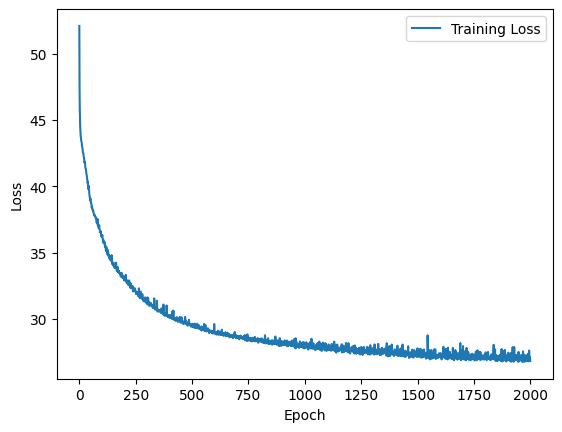

In [106]:
# Plot training loss
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()